# Classificação de Anúncios com K-Nearest Neighbors (KNN)


Neste laboratório, você irá treinar um modelo de K-Nearest Neighbors (KNN) para identificar anúncios de celulares em uma plataforma de e-commerce. O objetivo é entender como funciona cada etapa, praticar a implementação e avaliar o desempenho do modelo.

Siga as orientações de cada etapa com atenção. Este laboratório pode ser desenvolvido em dupla!

## Etapa 1: Importação de Bibliotecas

- Importe as bibliotecas necessárias:
  - `pandas` e `numpy`
  - `seaborn` e `matplotlib.pyplot`
  - `train_test_split` de `sklearn.model_selection`
  - `KNeighborsClassifier` de `sklearn.neighbors`.
  - `classification_report`, `confusion_matrix` e `accuracy_score` de `sklearn.metrics`
  - `LabelEncoder` e `MinMaxScaler` de `sklearn.preprocessing`



In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt

# Avaliação de desempenho
# Pré-processamento e avaliação
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Divisão de dados
from sklearn.model_selection import train_test_split

# Modelo KNN
from sklearn.neighbors import KNeighborsClassifier





## Etapa 2: Carregamento do Dataset

- O dataset será baixado diretamente do Google Drive utilizando o pacote `gdown`.
- Execute a célula abaixo para:
 - Instalar o gdown (caso ainda não esteja instalado);
 - Baixar o arquivo `ecommerce.csv` do Google Drive;
 - Carregar o conteúdo do CSV em um DataFrame.

In [ ]:
# Instalar o gdown (se ainda não estiver instalado)
!pip install -q gdown

# Baixar o dataset do Google Drive
import gdown

# Baixando um dataset 'ecommerce.csv' no formato CSV
!gdown '1TstOONoaFxkyQY534DWJAdCqiR_u90xV'

Downloading...
From: https://drive.google.com/uc?id=1TstOONoaFxkyQY534DWJAdCqiR_u90xV
To: /content/ecommerce.csv
100% 6.48k/6.48k [00:00<00:00, 19.8MB/s]


In [ ]:
# Utilize o pandas para ler o arquivo 'ecommerce.csv' e inspecionar os primeiros registros
df = pd.read_csv('ecommerce.csv')
df.head()

,Plataforma,Descrição do Produto,Link,Preço,Target
0,Bing,Smartphone Samsung Galaxy S21,https://produto1_v0.com,3392,1
1,Mercado Livre,Carregador portátil 20000mAh,https://produto2_v0.com,5806,0
2,Google,iPhone 13 novo,https://produto3_v0.com,3845,1
3,Google,Película de vidro temperado,https://produto4_v0.com,5101,0
4,Bing,Celular Xiaomi Redmi Note 11,https://produto5_v0.com,5062,1


## Etapa 3: Análise Exploratória dos Dados

Nesta etapa, você fará uma exploração visual e estatística dos dados para entender melhor a estrutura do dataset antes de treinar o modelo.

### Verifique a estrutura dos dados

Comece examinando o tamanho do conjunto de dados e o tipo de informação que ele contém:
- Use `.shape` para ver quantas linhas (amostras) e colunas (variáveis) o dataset possui.
- Use `.info()` para verificar os tipos de dados de cada coluna.
- Use `.isnull().sum()` para identificar se existem valores ausentes (nulos) em alguma coluna.

In [ ]:
# Dimensão do dataset
print(df.shape)
# Tipos de dados e não nulos
df.info()

# Contagem de valores nulos por coluna
df.isnull().sum()

(100, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Plataforma            100 non-null    object
 1   Descrição do Produto  100 non-null    object
 2   Link                  100 non-null    object
 3   Preço                 100 non-null    int64 
 4   Target                100 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


,0
Plataforma,0
Descrição do Produto,0
Link,0
Preço,0
Target,0


### Explore a distribuição da variável alvo (`Target`)
A variável `Target` indica se o anúncio é sobre celular (`1`) ou não (`0`). É importante verificar se temos um equilíbrio entre as classes.

Para isso, utilize:

- `sns.countplot(x='Target', data=df)`

Isso mostrará quantos anúncios são de celulares e quantos não são.

<Axes: xlabel='Target', ylabel='count'>

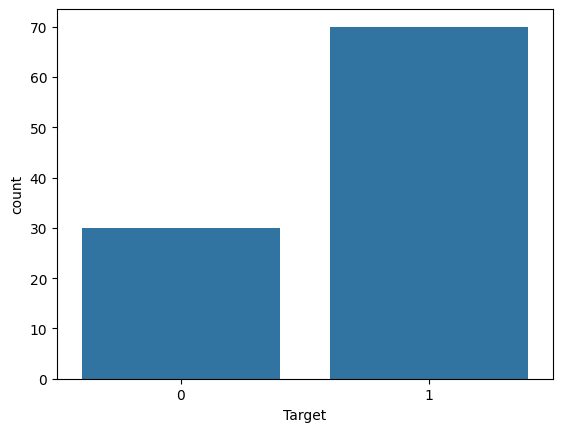

In [ ]:
# Contagem de classes
sns.countplot(x='Target', data=df)

### Analise a distribuição dos preços

Visualizar como os preços estão distribuídos pode ajudar a identificar valores atípicos ou faixas de preços predominantes.

Use o seguinte comando para gerar um histograma com linha de densidade:
- `sns.histplot(df['Preço'], kde=True)`


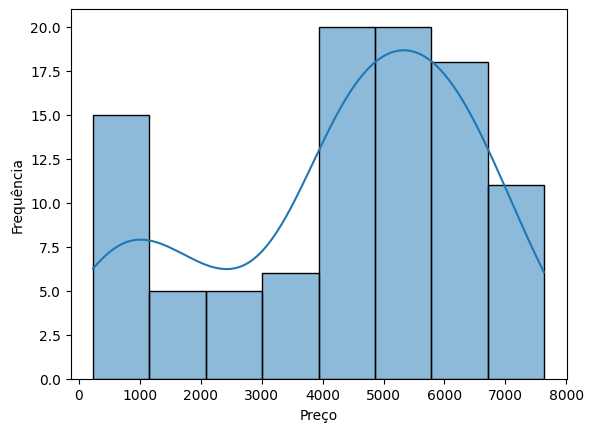

In [ ]:
# Histograma do preço
sns.histplot(df['Preço'], kde=True)
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

### Relacione a plataforma com os tipos de anúncio

Vamos agora verificar em quais plataformas aparecem mais anúncios de celulares ou não celulares.

Para isso, crie um gráfico com:
- `sns.countplot(x='Plataforma', hue='Target', data=df)`


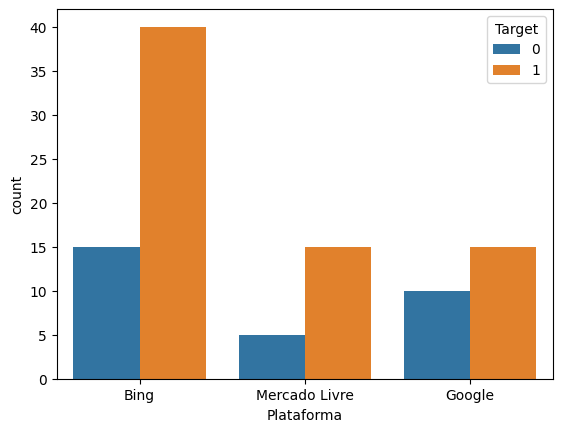

In [ ]:
# Comparação por Plataforma
sns.countplot(x='Plataforma', hue='Target', data=df)
plt.show()

## Etapa 4: Pré-processamento dos dados

- Codifique a variável categórica `Plataforma` com `LabelEncoder`.
- Normalize a variável numérica `Preço` com `MinMaxScaler`.

In [ ]:
# Codificação da variável categórica
le = LabelEncoder()
df['Plataforma']=le.fit_transform(df['Plataforma'])
df.head()

# Normalização do preço
scaler = MinMaxScaler()
df['Preço'] = scaler.fit_transform(df[['Preço']])
df.head()

,Plataforma,Descrição do Produto,Link,Preço,Target
0,0,Smartphone Samsung Galaxy S21,https://produto1_v0.com,0.426717,1
1,2,Carregador portátil 20000mAh,https://produto2_v0.com,0.753110,0
2,1,iPhone 13 novo,https://produto3_v0.com,0.487966,1
3,1,Película de vidro temperado,https://produto4_v0.com,0.657788,0
4,0,Celular Xiaomi Redmi Note 11,https://produto5_v0.com,0.652515,1


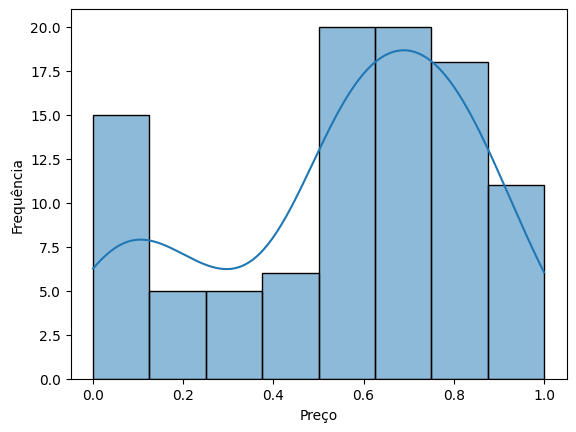

In [ ]:
# Histograma do preço
sns.histplot(df['Preço'], kde=True)
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

## Etapa 5: Separação dos dados

Agora, separe as variáveis independentes (`X`) da variável alvo (`y`) e utilize `train_test_split` para dividir em conjuntos de treino e teste.



In [ ]:
X = df[['Plataforma', 'Preço']]
#print(X.head())
y = df['Target']
#print(y.head())

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.3, random_state=42)


## Etapa 6: Treinamento do modelo

Treine o modelo KNN com os dados de treino.



In [ ]:
# Criando e treinando o modelo KNN
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=9)

## Etapa 7: Realização de Previsões com o Modelo

Agora que o modelo foi treinado, vamos utilizá-lo para realizar previsões sobre o conjunto de teste (`X_test`). Para isso, usamos o método `.predict()` do modelo KNN:

In [ ]:
# Realizando previsões
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1]


## Etapa 8: Avaliação do Desempenho do Modelo


Com as previsões armazenadas em `y_pred`, vamos avaliar o desempenho do modelo utilizando as seguintes métricas:

- Acurácia: representa a proporção de acertos do modelo.
- Matriz de Confusão: mostra como o modelo se saiu para cada classe (celular e não celular).
- Relatório de Classificação: inclui precisão, recall e F1-score para cada classe.

In [ ]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7666666666666667
[[ 3  6]
 [ 1 20]]
              precision    recall  f1-score   support

           0       0.75      0.33      0.46         9
           1       0.77      0.95      0.85        21

    accuracy                           0.77        30
   macro avg       0.76      0.64      0.66        30
weighted avg       0.76      0.77      0.73        30



## Etapa 9: Variação do Valor de K no KNN (Gráfico de Acurácia)

Nesta etapa, vamos analisar como diferentes valores de `K` afetam a performance do modelo KNN.

- Treine o modelo utilizando valores de `K` variando de 1 até 20.
- Para cada valor, calcule a acurácia no conjunto de teste.
- Armazene os resultados em uma lista.
- Por fim, plote um gráfico com os valores de `K` no eixo `X` e as acurácias no eixo `Y`.

Esse gráfico nos ajudará a visualizar qual valor de K oferece o melhor desempenho para o modelo.

Use o `matplotlib.pyplot` para construir o gráfico com marcadores (`marker='o'`), linhas conectando os pontos e grade ativada (`plt.grid(True)`).

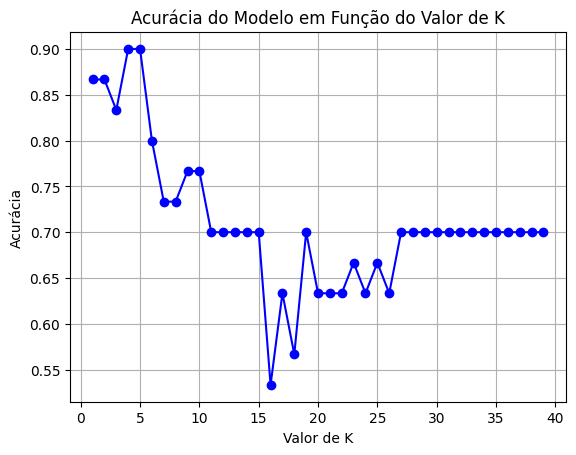

In [ ]:
# Lista para armazenar as acurácias
accuracies = []

# Lista de valores de K a serem testados
# K de 1 a 20
k_values = list(range(1, 40))

# Loop para treinar e avaliar o modelo para cada valor de K
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  accuracies.append(acc)

# Plotando o gráfico
plt.figure()
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.title('Acurácia do Modelo em Função do Valor de K')
plt.grid(True)
plt.show()

## Etapa 10: Visualização Gráfica das Métricas

Agora que avaliamos o modelo com números, vamos visualizar os resultados de forma gráfica. Isso ajuda a interpretar o desempenho do modelo de forma mais clara e intuitiva.

A matriz de confusão mostra quantas previsões foram corretas e incorretas para cada classe:
- A diagonal principal representa os acertos.
- Os valores fora da diagonal indicam erros de classificação.

Para visualizar, utilize o `seaborn.heatmap`.

### Métricas por Classe (Gráfico de Barras)

Vamos visualizar, para cada classe (Celular e Não Celular), os seguintes indicadores:
- Precisão (Precision): quantos dos itens classificados como positivos realmente são positivos.
-  Revocação (Recall): quantos dos itens positivos foram corretamente identificados.
-  F1-score: média harmônica entre precisão e recall.

Para isso, utilize `matplotlib.pyplot` para gerar um gráfico de barras com as três métricas lado a lado para cada classe.
